# Assignment 4

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
batch_size = 128
epochs     = 25

print(f"Using device: {device}")

Using device: cuda


## Dataset: AFHQ

In [3]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root='../stargan-v2/data/afhq/train', transform=transform)
val_dataset = datasets.ImageFolder(root='../stargan-v2/data/afhq/val',   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, drop_last=True)
val_loader= DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, drop_last=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train samples: 14630
Val samples: 1500
Classes: ['cat', 'dog', 'wild']


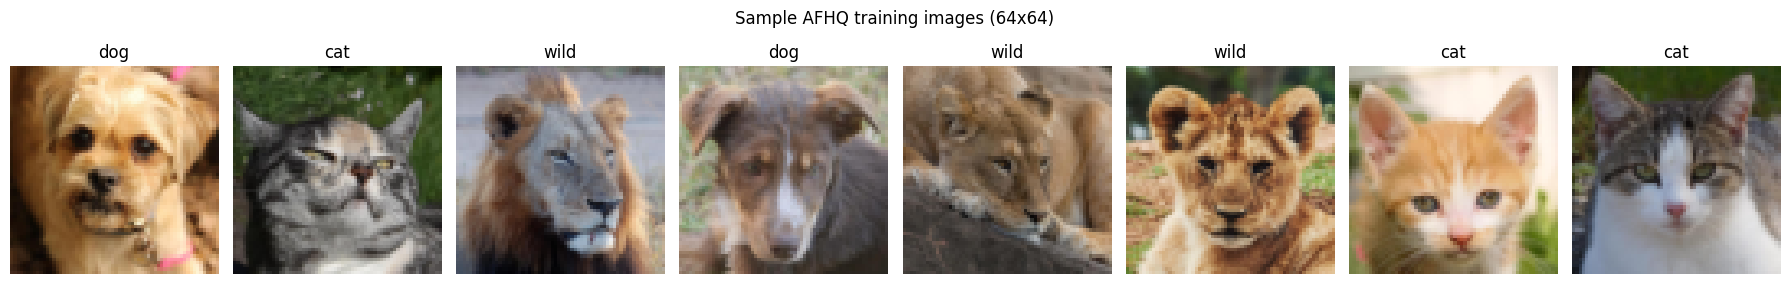

In [4]:
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].permute(1, 2, 0).numpy())
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis('off')
plt.suptitle("Sample AFHQ training images (64x64)")
plt.tight_layout()
plt.show()

## Convolutional VAE Architecture

In [5]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,  64,  4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,  128, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

tmp = ConvVAE(latent_dim)
print(f"ConvVAE parameters: {count_params(tmp):,}")
tmp

ConvVAE parameters: 2,957,251


ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(3

## b-VAE Effect of KL-divergence Weight

The ELBO loss is:


We train 4 models with **b = [0.05, 0.1, 1.0, 10.0]** to study the reconstruction-vs-disentanglement trade-off.

In [6]:
def vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld

In [7]:
def train_convvae(beta_val):
    model     = ConvVAE(latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    writer    = SummaryWriter(f"runs/ConvVAE_beta_{beta_val}")
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for imgs, _ in tqdm(train_loader, desc=f"Train β={beta_val} ep={epoch}", leave=False):
            imgs = imgs.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(imgs)
            loss = vae_loss(recon, imgs, mu, logvar, beta_val)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_dataset)
        history['train_loss'].append(avg_train)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs_v, _ in tqdm(val_loader, desc=f"Val   β={beta_val} ep={epoch}", leave=False):
                imgs_v = imgs_v.to(device)
                recon_v, mu_v, logvar_v = model(imgs_v)
                val_loss += vae_loss(recon_v, imgs_v, mu_v, logvar_v, beta_val).item()

        avg_val = val_loss / len(val_dataset)
        history['val_loss'].append(avg_val)

        writer.add_scalar('Loss/Train',      avg_train, epoch)
        writer.add_scalar('Loss/Validation', avg_val,   epoch)
        writer.add_images(
            'Reconstructions',
            torch.cat([imgs_v[:8], recon_v[:8]], 0),
            epoch
        )

        print(f"β={beta_val} | Epoch {epoch:02d} | Train {avg_train:.2f} | Val {avg_val:.2f}")

    writer.close()
    return {'model': model, 'history': history, 'beta': beta_val}

In [10]:
betas   = [0.05, 0.1, 1.0, 10.0]
results = {b: train_convvae(b) for b in betas}

Train β=0.05 ep=0:   0%|          | 0/114 [00:00<?, ?it/s]

β=0.05 | Epoch 00 | Train 498.82 | Val 323.23


β=0.05 | Epoch 01 | Train 285.45 | Val 255.18


β=0.05 | Epoch 02 | Train 232.99 | Val 207.84


β=0.05 | Epoch 03 | Train 198.96 | Val 187.06


...

β=10.0 | Epoch 20 | Train 417.38 | Val 415.40


β=10.0 | Epoch 21 | Train 417.40 | Val 417.24


β=10.0 | Epoch 22 | Train 416.82 | Val 415.74


β=10.0 | Epoch 23 | Train 416.77 | Val 417.96


β=10.0 | Epoch 24 | Train 417.39 | Val 414.93


In [11]:
# betas_2   = [0.5, 5.0]
# for b in betas_2:
#     results[b] = train_convvae(b)

# betas = betas + betas_2

### Plot Loss Curves for Each β

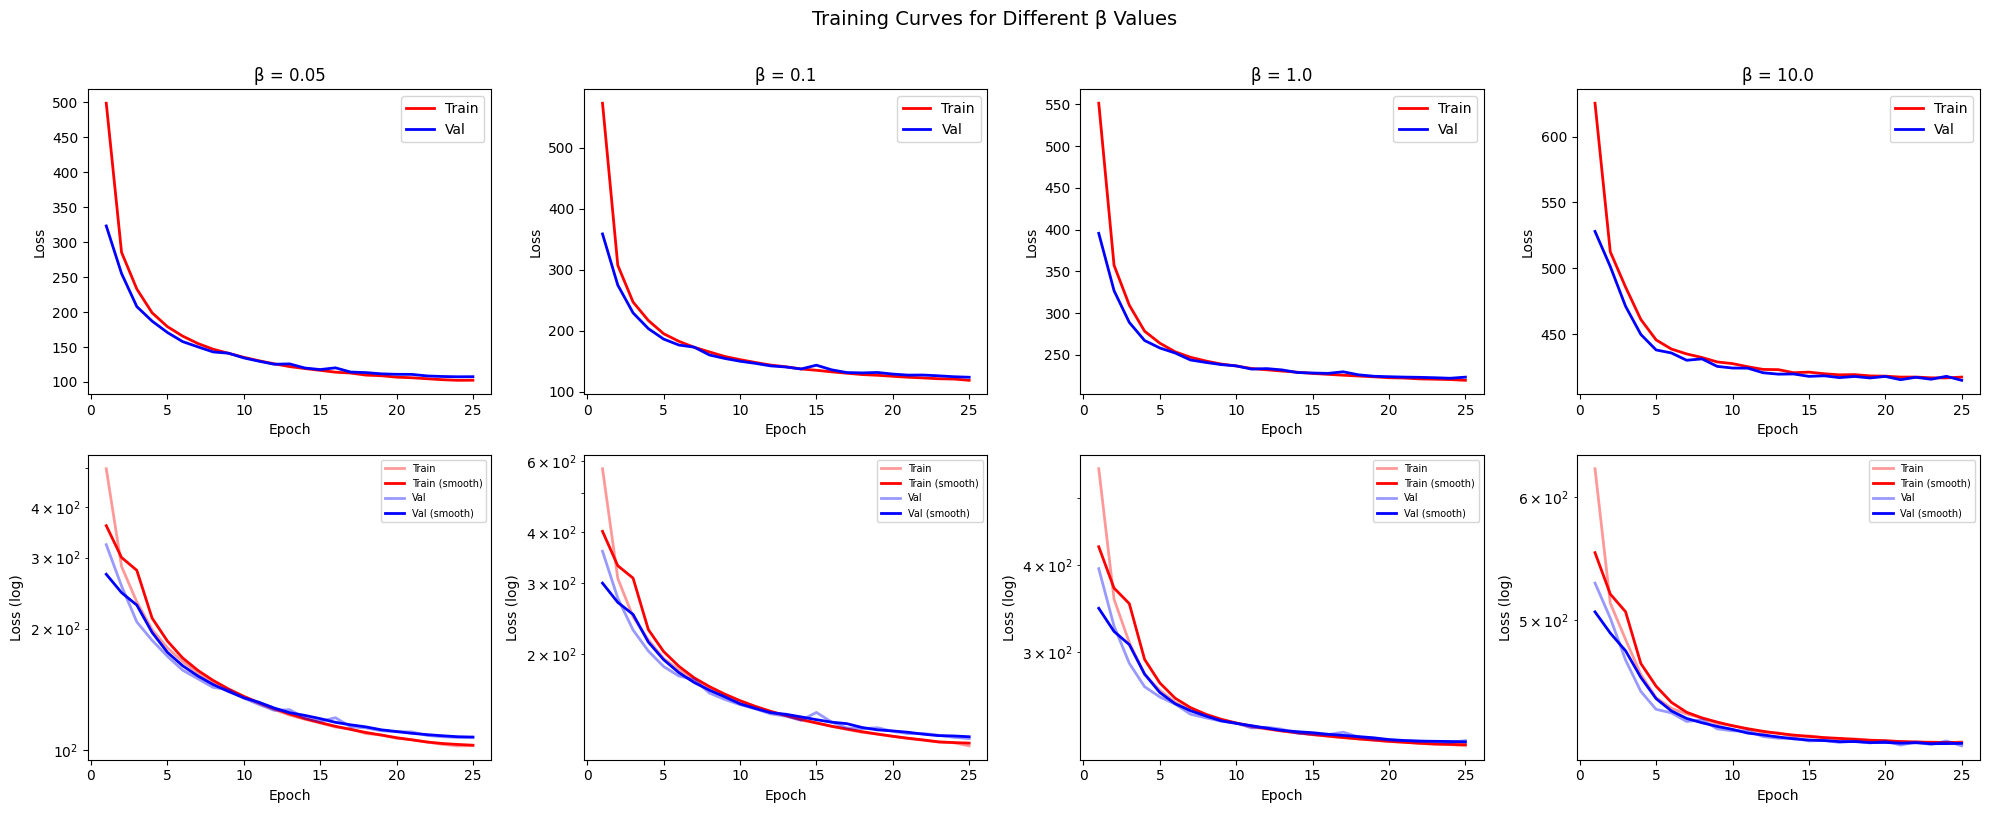

In [20]:
def smooth(f, K=5):
    """Low-pass smoothing via uniform kernel of size K."""
    kernel   = np.ones(K) / K
    f_padded = np.concatenate([f[:K//2], f, f[-K//2:]])
    return np.convolve(f_padded, kernel, mode='same')[K//2: -K//2]


fig, axes = plt.subplots(2, len(betas), figsize=(20, 8))

for col, b in enumerate(betas):
    hist   = results[b]['history']
    ep_ax  = np.arange(1, len(hist['train_loss']) + 1)

    ax0 = axes[0, col]
    ax0.plot(ep_ax, hist['train_loss'], c='red',  label='Train', linewidth=2)
    ax0.plot(ep_ax, hist['val_loss'],   c='blue', label='Val',   linewidth=2)
    ax0.set_title(f'β = {b}')  
    ax0.set_xlabel('Epoch')
    ax0.set_ylabel('Loss')
    ax0.legend()

    ax1 = axes[1, col]
    ax1.plot(ep_ax, hist['train_loss'],           c='red',  linewidth=2, alpha=0.4, label='Train')
    ax1.plot(ep_ax, smooth(hist['train_loss'], 5), c='red',  linewidth=2, label='Train (smooth)')
    ax1.plot(ep_ax, hist['val_loss'],              c='blue', linewidth=2, alpha=0.4, label='Val')
    ax1.plot(ep_ax, smooth(hist['val_loss'], 5),   c='blue', linewidth=2, label='Val (smooth)')
    ax1.set_yscale('log')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (log)')
    ax1.legend(fontsize=7)

plt.suptitle('Training Curves for Different β Values', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## d – Image Generation & Latent Space Exploration

In [21]:
def generate_random_images(model, num_images: int = 16, title: str = ""):
    model.eval()
    with torch.no_grad():
        z    = torch.randn(num_images, latent_dim, device=device)
        imgs = model.decode(z)
        grid = vutils.make_grid(imgs, nrow=4, padding=2, normalize=False)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Random Samples - {title}")
    plt.axis('off')
    plt.show()


def visualize_interpolation(model, n_steps: int = 10, title: str = ""):
    model.eval()
    with torch.no_grad():
        z1 = torch.randn(1, latent_dim, device=device)
        z2 = torch.randn(1, latent_dim, device=device)
        alphas = torch.linspace(0, 1, n_steps, device=device).unsqueeze(1)
        z_interp = z1*(1 - alphas)+z2*alphas
        imgs = model.decode(z_interp)
        grid = vutils.make_grid(imgs, nrow=n_steps, padding=2)

    plt.figure(figsize=(16, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Latent Space Interpolation – {title}")
    plt.axis('off')
    plt.show()


β = 0.05


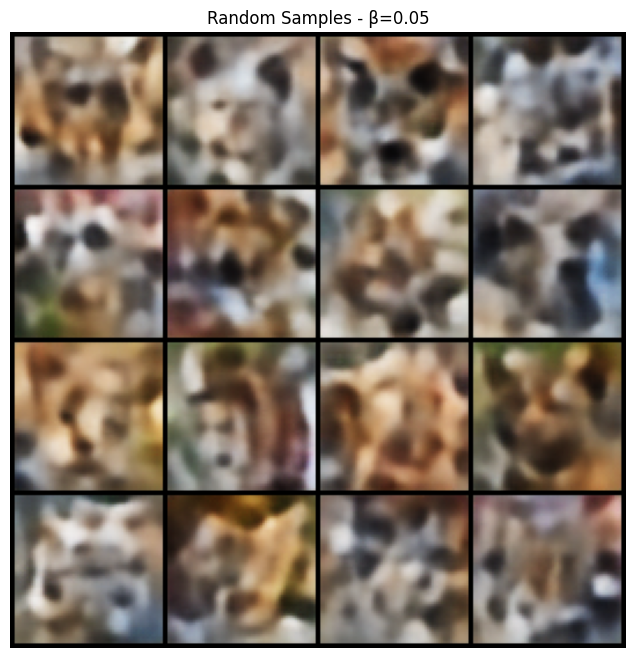

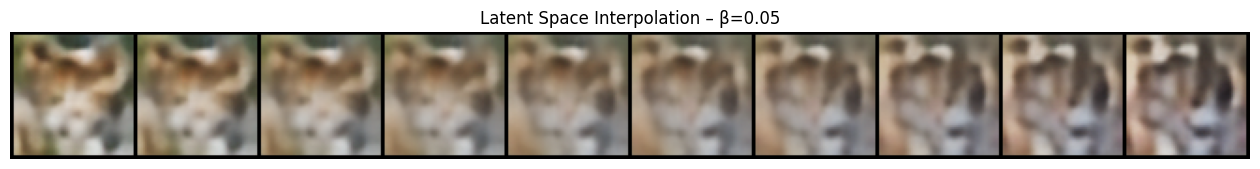


β = 0.1


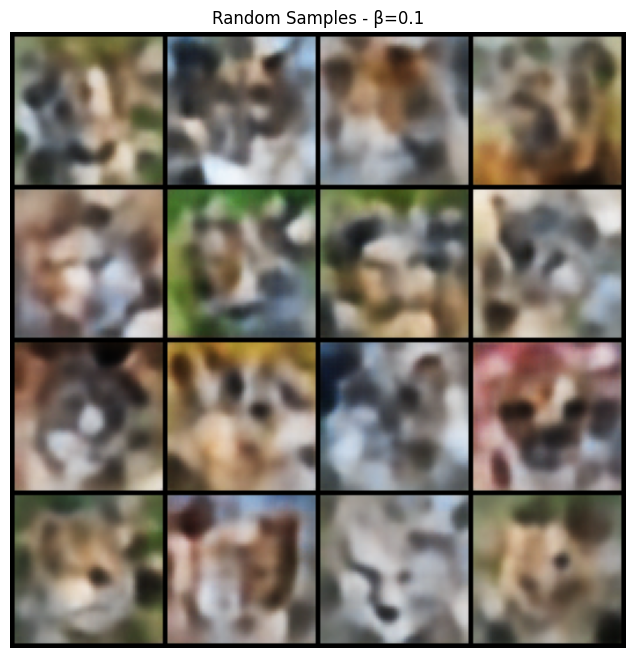

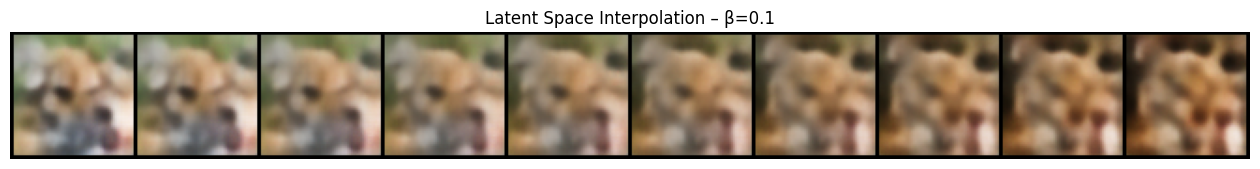


β = 1.0


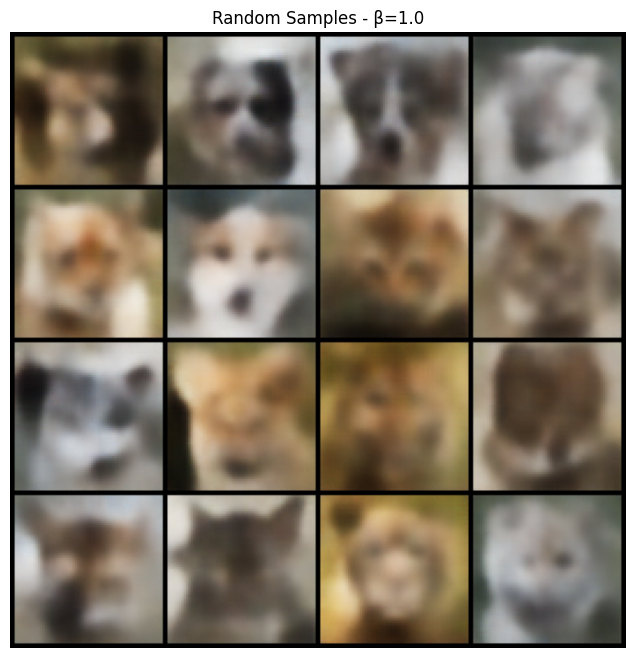

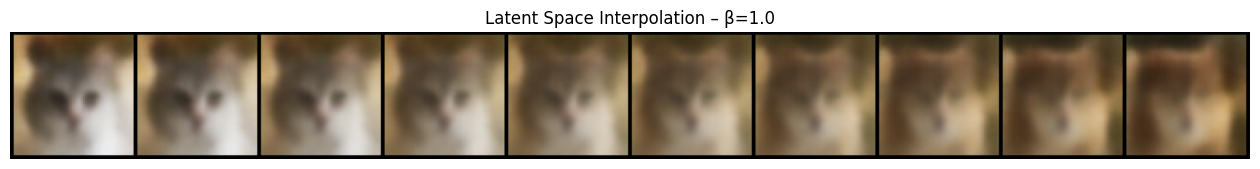


β = 10.0


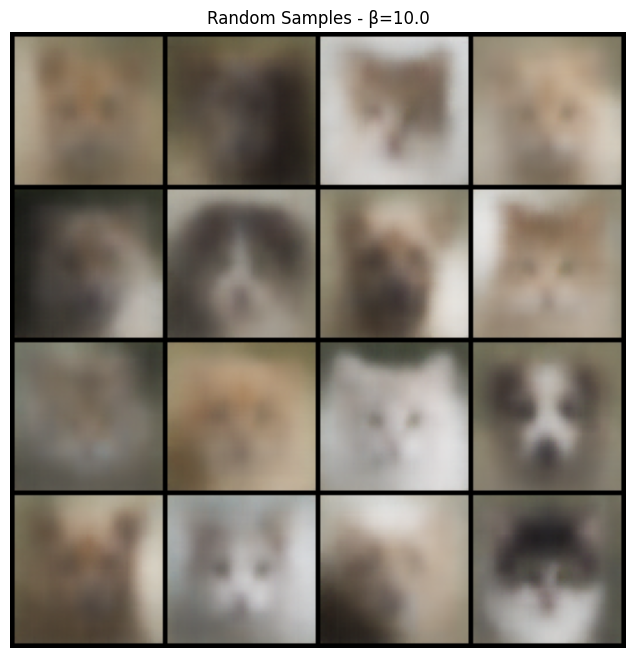

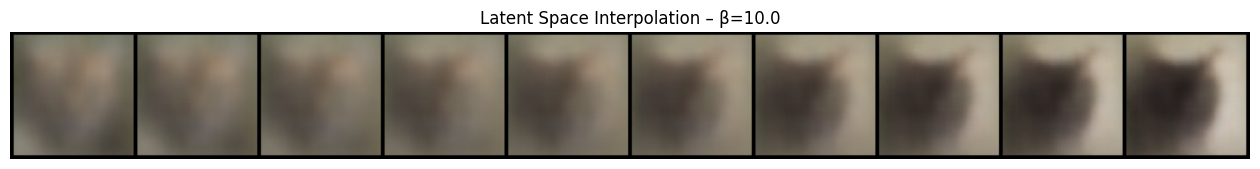

In [22]:
for b in betas:
    m = results[b]['model']
    print(f"\n{'='*60}\nβ = {b}\n{'='*60}")
    generate_random_images(m, num_images=16, title=f"β={b}")
    visualize_interpolation(m, n_steps=10,   title=f"β={b}")

### 2-D PCA Visualisation of the Latent Space

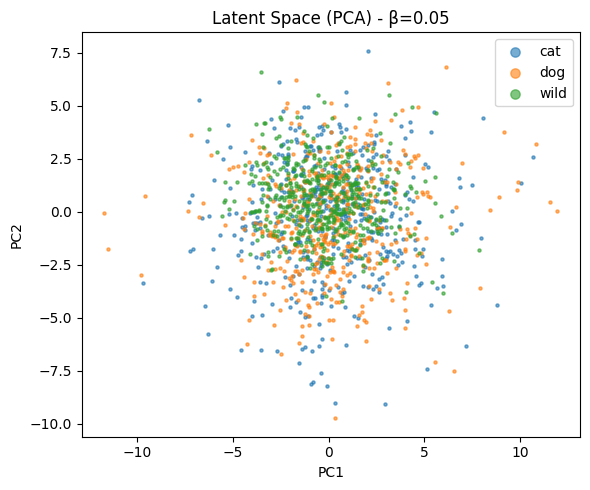

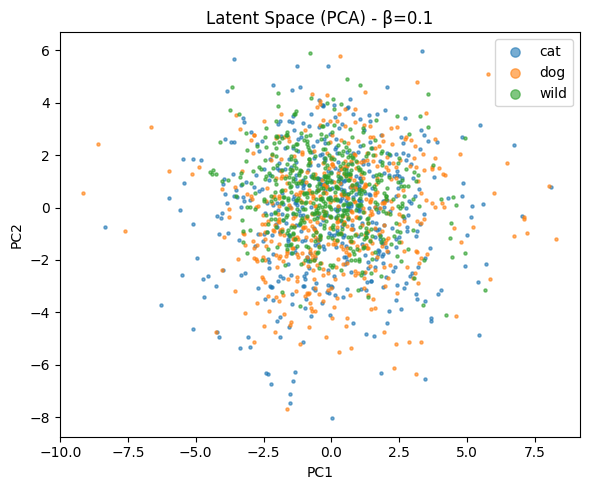

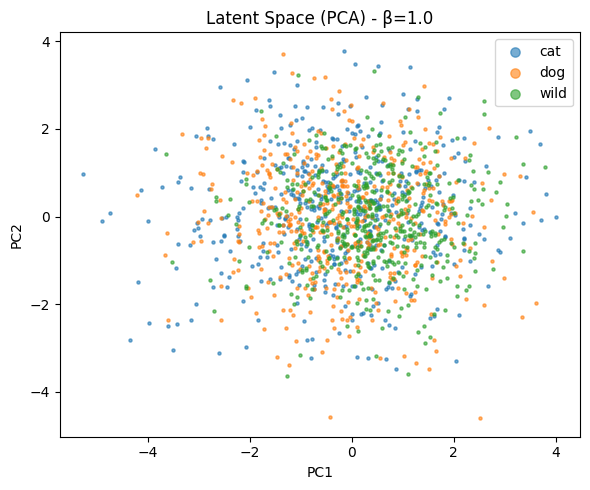

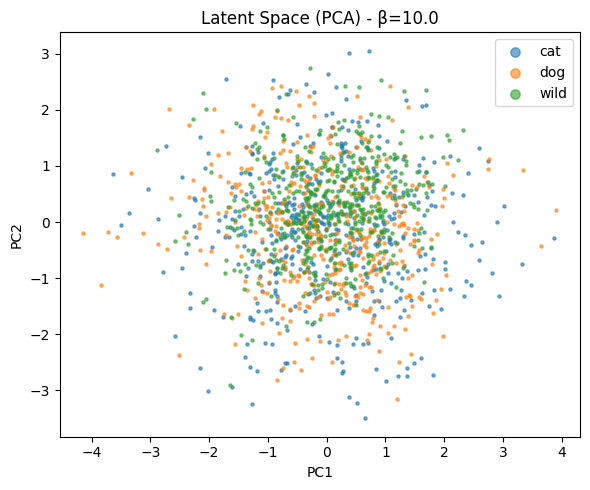

In [23]:
from sklearn.decomposition import PCA

def plot_latent_pca(model, loader, title: str = "", max_batches: int = 20):
    """Encode validation images and project u to 2-D with PCA."""
    model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(loader):
            if i >= max_batches:
                break
            mu, _ = model.encode(imgs.to(device))
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    mu_np  = np.concatenate(all_mu,     axis=0)
    lbl_np = np.concatenate(all_labels, axis=0)
    pca2d  = PCA(n_components=2).fit_transform(mu_np)

    plt.figure(figsize=(6, 5))
    for c, cls_name in enumerate(val_dataset.classes):
        mask = lbl_np == c
        plt.scatter(pca2d[mask, 0], pca2d[mask, 1], s=5, label=cls_name, alpha=0.6)
    plt.legend(markerscale=3)
    plt.title(f"Latent Space (PCA) - {title}")
    plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()


for b in betas:
    plot_latent_pca(results[b]['model'], val_loader, title=f"β={b}")

## Comparison: Qualitative & Quantitative (FID)

### 1 Qualitative Comparison – Reconstructions Side by Side

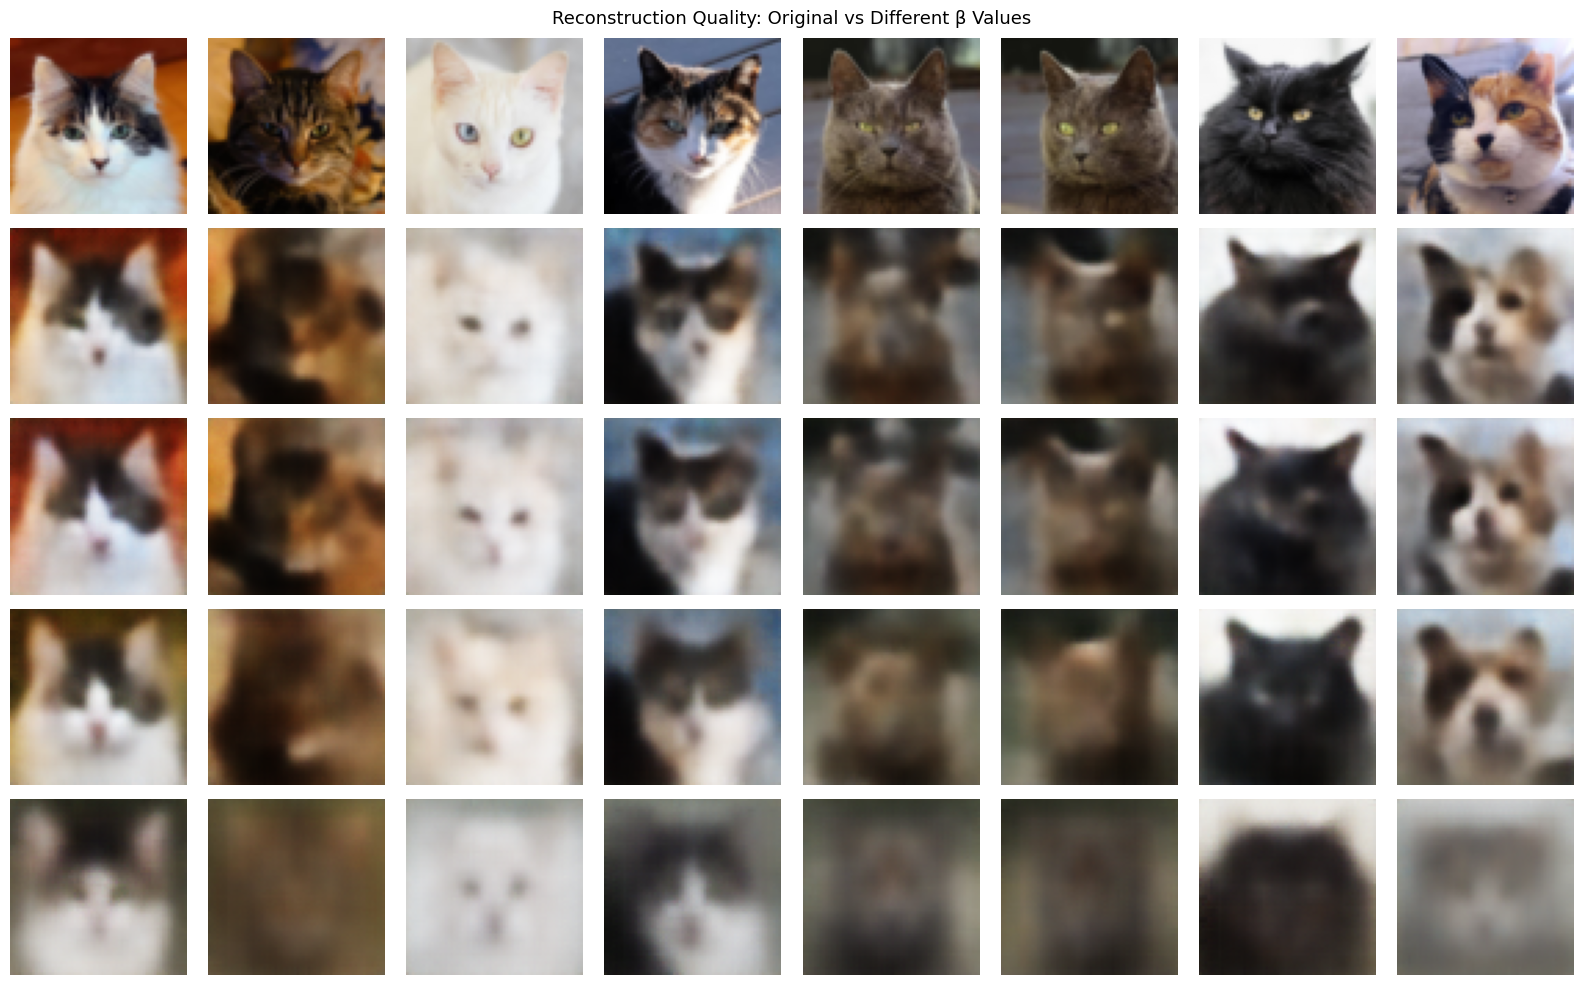

In [24]:
def show_reconstructions(results_dict, n: int = 8):
    imgs_v,_ = next(iter(val_loader))
    imgs_v = imgs_v[:n].to(device)

    rows = [imgs_v.cpu()]
    row_labels = ['Original']
    for b, res in results_dict.items():
        res['model'].eval()
        with torch.no_grad():
            recon, _, _ = res['model'](imgs_v)
        rows.append(recon.cpu())
        row_labels.append(f"β={b}")

    fig, axes = plt.subplots(len(rows), n, figsize=(2 * n, 2 * len(rows)))
    for r, (row_imgs, label) in enumerate(zip(rows, row_labels)):
        for c in range(n):
            axes[r, c].imshow(row_imgs[c].permute(1, 2, 0).numpy().clip(0, 1))
            axes[r, c].axis('off')
        axes[r, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=55)

    plt.suptitle('Reconstruction Quality: Original vs Different β Values', fontsize=13)
    plt.tight_layout()
    plt.show()


show_reconstructions(results)

### 2 Quantitative Comparison – Fréchet Inception Distance (FID)

FID measures the distance between the distribution of real images and generated images in the feature space of InceptionV3. Lower FID → better generation quality.

In [25]:
try:
    from pytorch_fid.inception import InceptionV3
    from pytorch_fid.fid_score import calculate_frechet_distance
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'pytorch-fid', '--quiet'], check=True)
    from pytorch_fid.inception import InceptionV3
    from pytorch_fid.fid_score import calculate_frechet_distance


In [26]:
inception = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]]).to(device).eval()

@torch.no_grad()
def get_inception_features(images: torch.Tensor) -> np.ndarray:
    images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
    feats = inception(images)[0]
    return feats.squeeze(-1).squeeze(-1).cpu().numpy()


@torch.no_grad()
def collect_features(model, n_samples: int = 2000):
    feats = []
    for _ in range(n_samples // batch_size + 1):
        z  = torch.randn(batch_size, latent_dim, device=device)
        gx = model.decode(z).clamp(0, 1)
        feats.append(get_inception_features(gx))
    return np.concatenate(feats, axis=0)[:n_samples]


@torch.no_grad()
def collect_real_features(loader, n_samples: int = 2000):
    feats = []
    for imgs, _ in loader:
        feats.append(get_inception_features(imgs.to(device)))
        if sum(f.shape[0] for f in feats) >= n_samples:
            break
    return np.concatenate(feats, axis=0)[:n_samples]


def compute_fid(real_feats: np.ndarray, gen_feats: np.ndarray) -> float:
    mu_r, sigma_r = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu_g, sigma_g = gen_feats.mean(0),  np.cov(gen_feats,  rowvar=False)
    return calculate_frechet_distance(mu_r, sigma_r, mu_g, sigma_g)

In [27]:
N_FID = 2000

print(f"Collecting real features ({N_FID} images)…")
real_feats = collect_real_features(val_loader, n_samples=N_FID)

fid_scores = {}
for b in betas:
    print(f"  Generating features for β={b}…")
    gen_feats    = collect_features(results[b]['model'], n_samples=N_FID)
    fid_scores[b] = compute_fid(real_feats, gen_feats)
    print(f"  FID (β={b}) = {fid_scores[b]:.2f}")

print("\nFID Summary:")
for b, fid in sorted(fid_scores.items(), key=lambda x: x[1]):
    print(f"  β={b:5.2f}  →  FID = {fid:.2f}")

  Generating features for β=0.05…
  FID (β=0.05) = 205.30
  Generating features for β=0.1…
  FID (β=0.1) = 214.03
  Generating features for β=1.0…
  FID (β=1.0) = 186.93
  Generating features for β=10.0…
  FID (β=10.0) = 211.26

FID Summary:
  β= 1.00  →  FID = 186.93
  β= 0.05  →  FID = 205.30
  β=10.00  →  FID = 211.26
  β= 0.10  →  FID = 214.03


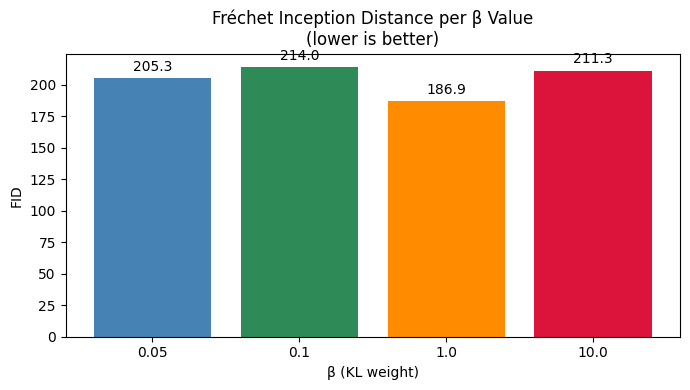

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([str(b) for b in betas], [fid_scores[b] for b in betas],
              color=['steelblue', 'seagreen', 'darkorange', 'crimson'])
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlabel('β (KL weight)')
ax.set_ylabel('FID')
ax.set_title('Fréchet Inception Distance per β Value\n(lower is better)')
plt.tight_layout()
plt.show()

### 3 Log Generated Images and Losses to TensorBoard

All scalars and image grids were already logged during training.  
Here we additionally log FID scores and final generated samples.

In [29]:
for b in betas:
    writer = SummaryWriter(f"runs/ConvVAE_beta_{b}")

    writer.add_scalar('FID', fid_scores[b], global_step=0)

    results[b]['model'].eval()
    with torch.no_grad():
        z_sample = torch.randn(16, latent_dim, device=device)
        gen_imgs = results[b]['model'].decode(z_sample).clamp(0, 1)
        grid = vutils.make_grid(gen_imgs, nrow=4, normalize=False)
    writer.add_image('Generated/final_grid', grid, global_step=0)

    writer.close()


### e.4 Discussion


- **0.05** : Very low KL penalty → decoder free to memorise → sharp reconstructions but potentially posterior collapse non-smooth latent space
- **0.1**  : Mild regularisation; good reconstruction quality with slightly better latent structure
- **1.0**  : Standard VAE; balanced trade-off between reconstruction fidelity and a well-regularised latent space
- **10.0** : Strong KL penalty → smooth, disentangled latent space but blurrier images; higher FID

**Key observations:**
- **Qualitative:** Low β -> sharper, more realistic-looking images. High β → blurrier reconstructions, but smoother interpolations.
- **Quantitative (FID):** FID typically has a sweet-spot around β = 0.1–1.0; very high β hurts generation quality because the reconstruction term is under-weighted.
- **Latent space (PCA):** High β produces more compact, class-separated clusters, consistent with disentanglement theory (Higgins et al., 2017).